In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(545, 13)

In [11]:
yes_no = [
'mainroad',
'guestroom',
'basement',
'hotwaterheating',
'airconditioning',
'prefarea'
]

for col in yes_no:
    df[col] = df[col].map({'yes':1,'no':0})

In [12]:
df = pd.get_dummies(df,
columns=['furnishingstatus'],
drop_first=True)

In [13]:
X = df.drop("price",axis=1)
y = df["price"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [15]:
lr = LinearRegression()

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
 pred_lr = lr.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test,pred_lr)
print(mae)

970043.4039201634


In [18]:
rmse=np.sqrt(mean_squared_error(y_test,pred_lr))
print(rmse)

1324506.9600914384


In [19]:
r2=r2_score(y_test,pred_lr)
print(r2)

0.6529242642153186


In [34]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)

In [35]:
mae_rf=mean_absolute_error(y_test,pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,pred_rf))
r2_rf=r2_score(y_test,pred_rf)

In [36]:
print(mae_rf)
print(rmse_rf)
print(r2_rf)

1022560.0527522935
1401496.8425384816
0.6114024924156645


In [37]:
print("Linear Regression")
print(mae)
print(rmse)
print(r2)
print()
print("Random Forest")
print(mae_rf)
print(rmse_rf)
print(r2_rf)

Linear Regression
970043.4039201634
1324506.9600914384
0.6529242642153186

Random Forest
1022560.0527522935
1401496.8425384816
0.6114024924156645


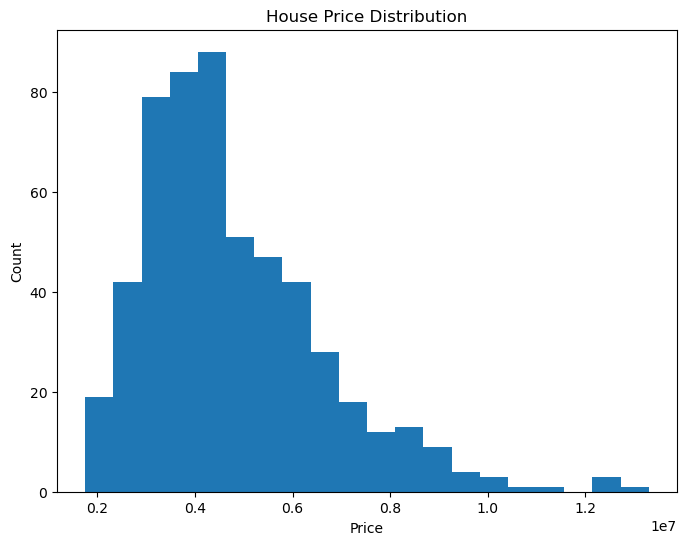

In [38]:
plt.figure(figsize=(8,6))
plt.hist(df['price'],bins=20)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("charts/histogram.png")
plt.show()

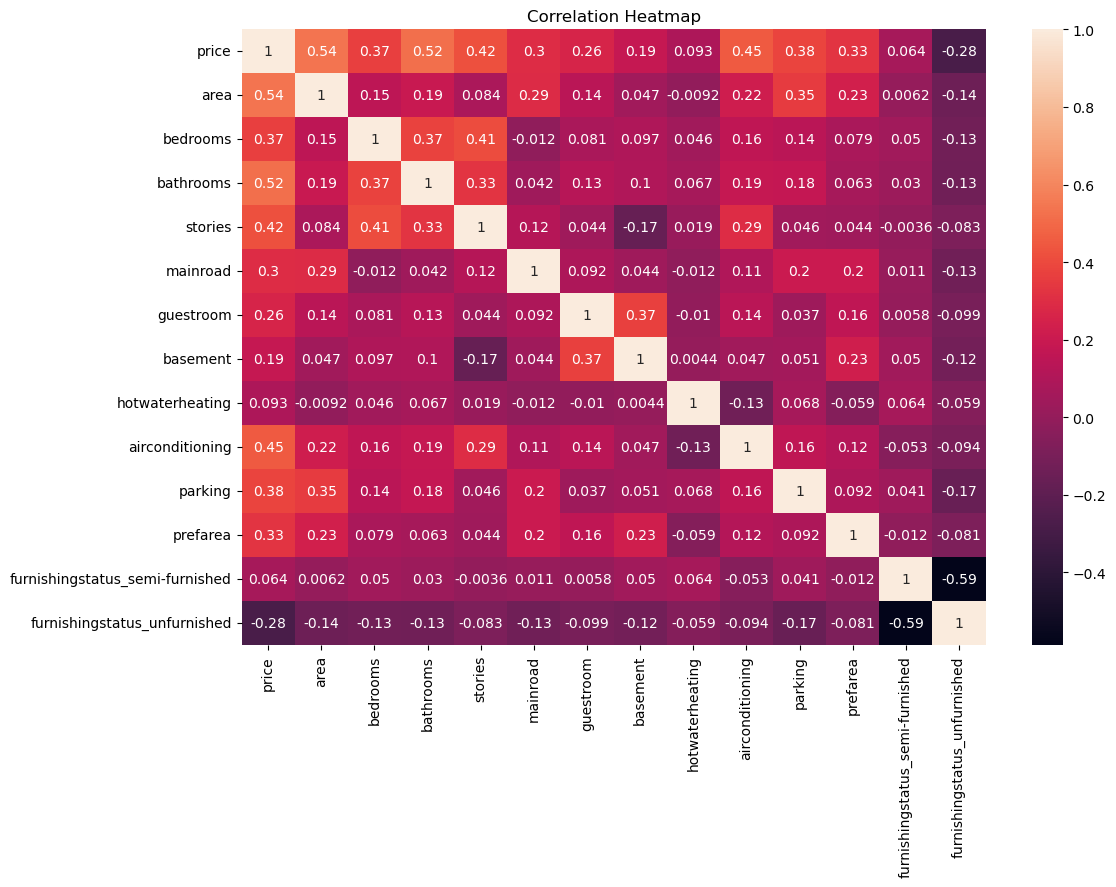

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.savefig("charts/heatmap.png")
plt.show()

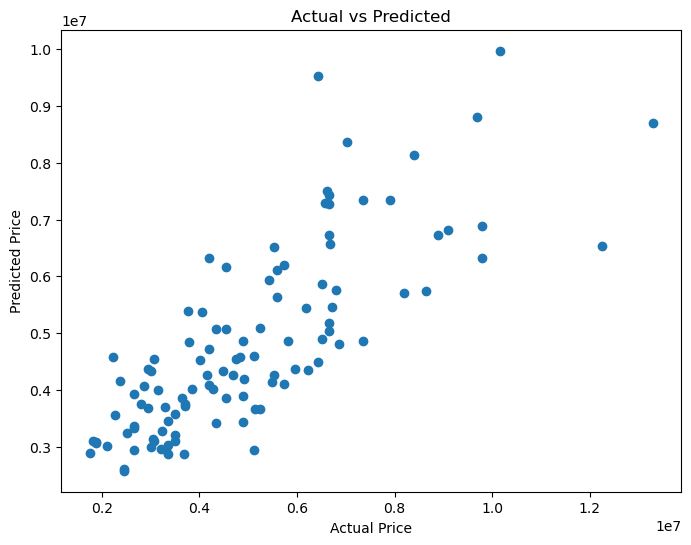

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.savefig("charts/prediction.png")
plt.show()